# K-means 클러스터링 기반 고객 군집 분석

## 분석 목적

앞선 RFM 분석에서는 사전 정의된 규칙(R/F/M 임계값)으로 고객을 분류했다.
이 노트북에서는 같은 RFM 변수를 입력으로 K-means 클러스터링을 적용하여,
데이터 기반으로 자연스러운 군집을 찾고 두 접근법의 결과를 비교한다.

## 분석 흐름

1. RFM 변수 표준화 (StandardScaler)
2. 최적 클러스터 수 결정 (Elbow method, Silhouette score)
3. K-means 클러스터링 수행
4. 클러스터 특성 분석 및 시각화
5. 규칙 기반 RFM 세그먼트와 비교

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# 한글 폰트 강제 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

fm.fontManager.addfont(font_path)
mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = font_name

sns.set_style("whitegrid", {"font.family": font_name})
plt.rcParams['figure.figsize'] = (12, 5)

# 이전 노트북의 RFM 결과 로드
rfm = pd.read_csv('../data/rfm_result.csv')

print(f"적용된 폰트: {font_name}")
print(f"데이터 로드 완료: {len(rfm):,}명")
rfm.head()

적용된 폰트: Malgun Gothic
데이터 로드 완료: 93,358명


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414,9,Champions
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411,6,Potential
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112,4,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211,4,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215,8,At Risk


## 1. 변수 표준화

K-means는 거리 기반 알고리즘이므로 변수의 스케일이 결과에 큰 영향을 미친다.
Recency, Frequency, Monetary는 단위와 분포가 모두 다르므로 표준화가 필수다.

또한 Monetary는 분포가 강한 우편향(right-skewed)을 보이므로
log 변환을 먼저 적용한 후 StandardScaler로 표준화한다.

In [2]:
# 클러스터링에 사용할 변수
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Monetary는 분포가 매우 치우쳐 있어 log 변환
features['Monetary'] = np.log1p(features['Monetary'])

# 표준화
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(
    features_scaled,
    columns=['R_scaled', 'F_scaled', 'M_scaled']
)

print("표준화 결과 통계:")
print(features_scaled.describe().round(3))

표준화 결과 통계:
        R_scaled   F_scaled   M_scaled
count  93358.000  93358.000  93358.000
mean      -0.000     -0.000      0.000
std        1.000      1.000      1.000
min       -1.553     -0.160     -4.191
25%       -0.812     -0.160     -0.651
50%       -0.124     -0.160      0.024
75%        0.708     -0.160      0.609
max        3.120     66.795      5.436


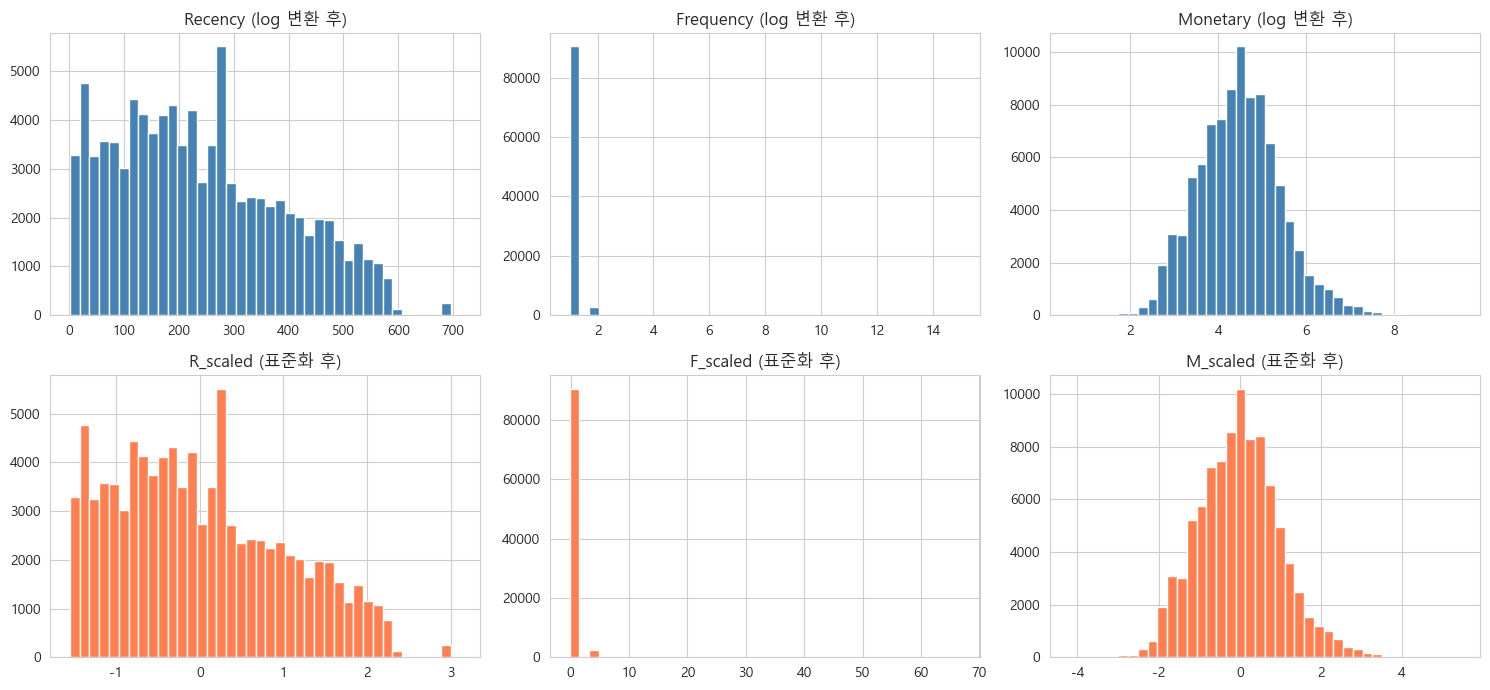

In [3]:
# 변환 전후 분포 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# 변환 후 (log 적용)
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(features[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} (log 변환 후)')

# 표준화 후
for i, col in enumerate(features_scaled.columns):
    axes[1, i].hist(features_scaled[col], bins=40, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{col} (표준화 후)')

plt.tight_layout()
plt.show()

## 2. 최적 클러스터 수 (k) 결정

두 가지 지표로 최적의 k를 함께 평가한다.

- **Elbow method**: SSE(Within-Cluster Sum of Squares)가 급격히 감소하다가 완만해지는 지점
- **Silhouette score**: -1 ~ +1 범위, 1에 가까울수록 잘 구분된 군집화

Silhouette은 표본 크기가 크면 계산 비용이 크므로 10,000명 샘플로 평가한다.

In [4]:
# k = 2 ~ 10 범위에서 평가
k_range = range(2, 11)
sse_list = []
silhouette_list = []

# Silhouette 계산용 샘플
sample_size = 10000
sample_idx = np.random.RandomState(42).choice(
    len(features_scaled), sample_size, replace=False
)
sample_data = features_scaled.iloc[sample_idx].values

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    sse_list.append(kmeans.inertia_)
    
    labels = kmeans.predict(sample_data)
    sil = silhouette_score(sample_data, labels)
    silhouette_list.append(sil)
    
    print(f"k={k}: SSE={kmeans.inertia_:.0f}, Silhouette={sil:.4f}")

k=2: SSE=201008, Silhouette=0.6865
k=3: SSE=137085, Silhouette=0.3562
k=4: SSE=97077, Silhouette=0.3664
k=5: SSE=81452, Silhouette=0.3453
k=6: SSE=70492, Silhouette=0.3376
k=7: SSE=61047, Silhouette=0.3400
k=8: SSE=52011, Silhouette=0.3556
k=9: SSE=46949, Silhouette=0.3414
k=10: SSE=42904, Silhouette=0.3417


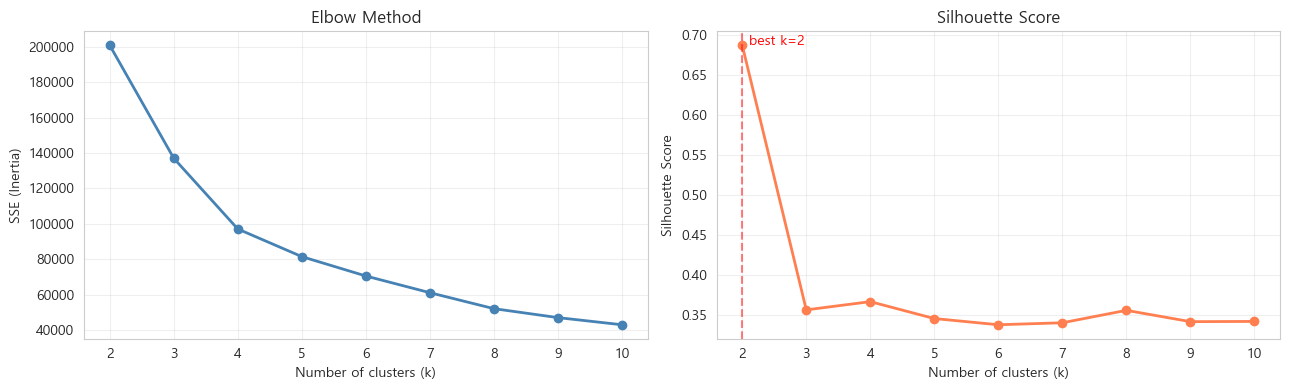

최고 Silhouette 지점: k=2 (0.6865)


In [5]:
# Elbow + Silhouette 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), sse_list, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('SSE (Inertia)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_list, marker='o', linewidth=2, color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

best_k = list(k_range)[np.argmax(silhouette_list)]
best_sil = max(silhouette_list)
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.5)
axes[1].text(best_k + 0.1, best_sil, f'best k={best_k}', color='red')

plt.tight_layout()
plt.show()

print(f"최고 Silhouette 지점: k={best_k} ({best_sil:.4f})")

## 3. K-means 적용

Elbow와 Silhouette 결과를 종합해 k를 결정한다.
Silhouette 최고점이 너무 작은 k(예: k=2)인 경우, 비즈니스 해석 가능성을 고려해
약간 큰 k(3~5)를 선택하는 것이 일반적이다.

본 분석에서는 **k=4**로 진행한다.
(필요시 위 셀의 best_k 결과를 참고해 조정)

In [6]:
# 최종 k 선택
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(features_scaled)

# 클러스터별 크기
cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / len(rfm) * 100).round(2)

result = pd.DataFrame({
    '고객 수': cluster_counts,
    '비율(%)': cluster_pct
})

print(f"K-means 클러스터링 결과 (k={K})")
print("=" * 50)
print(result)

K-means 클러스터링 결과 (k=4)
          고객 수  비율(%)
Cluster              
0        31028  33.24
1        32386  34.69
2        27143  29.07
3         2801   3.00


In [7]:
# 클러스터별 RFM 평균값과 매출 기여도
cluster_summary = rfm.groupby('Cluster').agg(
    고객수=('customer_unique_id', 'count'),
    평균_Recency=('Recency', 'mean'),
    평균_Frequency=('Frequency', 'mean'),
    평균_Monetary=('Monetary', 'mean'),
    총_Monetary=('Monetary', 'sum')
).round(2)

total_revenue = rfm['Monetary'].sum()
cluster_summary['매출비중(%)'] = (
    cluster_summary['총_Monetary'] / total_revenue * 100
).round(2)
cluster_summary['고객비중(%)'] = (
    cluster_summary['고객수'] / len(rfm) * 100
).round(2)

cluster_summary = cluster_summary.sort_values('매출비중(%)', ascending=False)

print("클러스터별 특성")
print("=" * 90)
print(cluster_summary)

클러스터별 특성
           고객수  평균_Recency  평균_Frequency  평균_Monetary  총_Monetary  매출비중(%)  \
Cluster                                                                      
1        32386      161.23          1.00       251.02  8129425.71    61.49   
2        27143      426.35          1.00       110.00  2985746.20    22.58   
0        31028      154.78          1.00        44.41  1377917.45    10.42   
3         2801      220.29          2.11       260.05   728408.75     5.51   

         고객비중(%)  
Cluster           
1          34.69  
2          29.07  
0          33.24  
3           3.00  


## 4. 클러스터 해석

각 클러스터를 RFM 평균값으로 해석하고 비즈니스 의미가 있는 이름을 부여한다.

위 표의 평균_Recency / 평균_Monetary / 평균_Frequency를 보고
각 클러스터가 어떤 고객 그룹에 해당하는지 판단한다.

예시 해석 기준:
- Recency 낮음 + Monetary 높음 -> VIP 또는 Champions
- Recency 높음 + Frequency 낮음 -> 휴면/이탈 고객
- Recency 낮음 + Frequency 낮음 -> 신규 고객
- Frequency 높음 -> 충성 고객

In [8]:
# 클러스터에 의미있는 이름 부여
# 위 셀의 결과를 보고 각 클러스터 번호에 맞는 이름을 매핑
# (실제 결과를 보고 수정 필요 - 아래는 일반적인 예시)

cluster_names = {
    0: '최근 저액 구매자',
    1: '최근 고액 구매자',
    2: '휴면 고객',
    3: '충성 재구매 고객',
}

rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

# 임의 이름 부여 후 다시 요약
named_summary = rfm.groupby('Cluster_Name').agg(
    고객수=('customer_unique_id', 'count'),
    평균_Recency=('Recency', 'mean'),
    평균_Frequency=('Frequency', 'mean'),
    평균_Monetary=('Monetary', 'mean'),
).round(2)

print(named_summary)

                고객수  평균_Recency  평균_Frequency  평균_Monetary
Cluster_Name                                              
최근 고액 구매자     32386      161.23          1.00       251.02
최근 저액 구매자     31028      154.78          1.00        44.41
충성 재구매 고객      2801      220.29          2.11       260.05
휴면 고객         27143      426.35          1.00       110.00


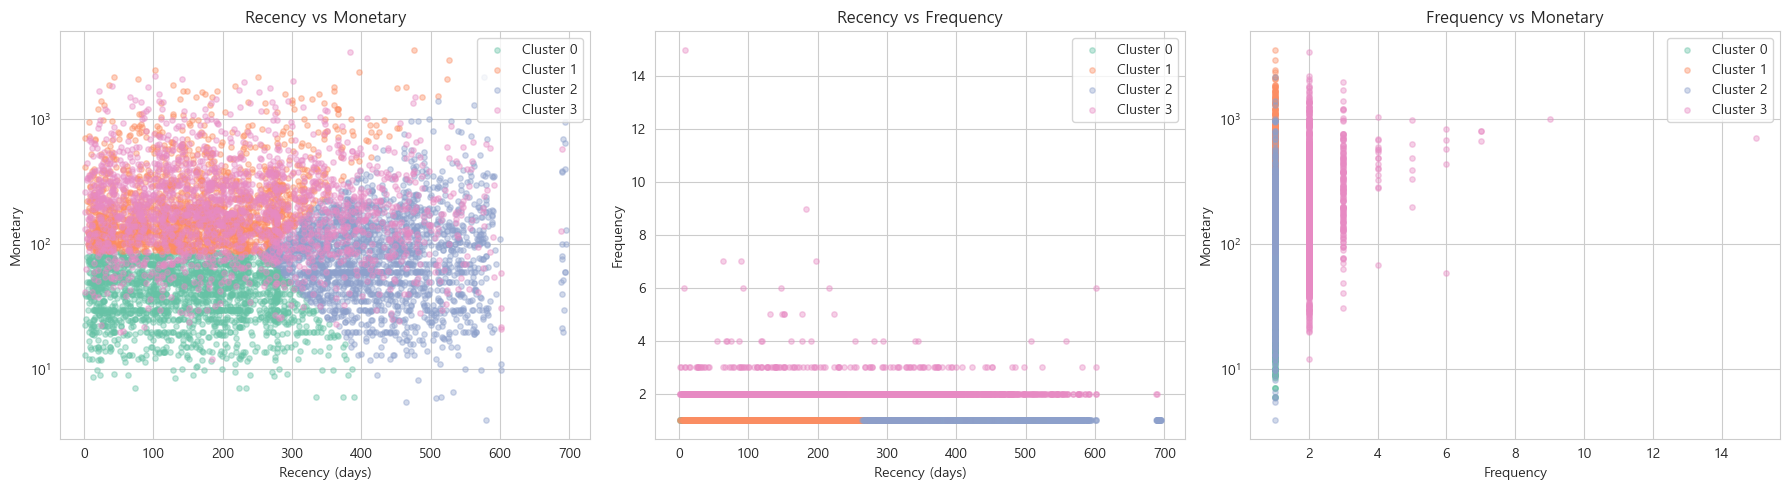

In [9]:
# 클러스터 시각화 (2D 산점도 3개 조합)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 색상 팔레트
palette = sns.color_palette('Set2', K)

# R vs M
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster].sample(
        min(2000, len(rfm[rfm['Cluster'] == cluster])), random_state=42
    )
    axes[0].scatter(subset['Recency'], subset['Monetary'],
                    alpha=0.4, s=15, color=palette[cluster],
                    label=f'Cluster {cluster}')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary')
axes[0].set_yscale('log')
axes[0].set_title('Recency vs Monetary')
axes[0].legend()

# R vs F
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster].sample(
        min(2000, len(rfm[rfm['Cluster'] == cluster])), random_state=42
    )
    axes[1].scatter(subset['Recency'], subset['Frequency'],
                    alpha=0.4, s=15, color=palette[cluster],
                    label=f'Cluster {cluster}')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Recency vs Frequency')
axes[1].legend()

# F vs M
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster].sample(
        min(2000, len(rfm[rfm['Cluster'] == cluster])), random_state=42
    )
    axes[2].scatter(subset['Frequency'], subset['Monetary'],
                    alpha=0.4, s=15, color=palette[cluster],
                    label=f'Cluster {cluster}')
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Monetary')
axes[2].set_yscale('log')
axes[2].set_title('Frequency vs Monetary')
axes[2].legend()

plt.tight_layout()
plt.show()

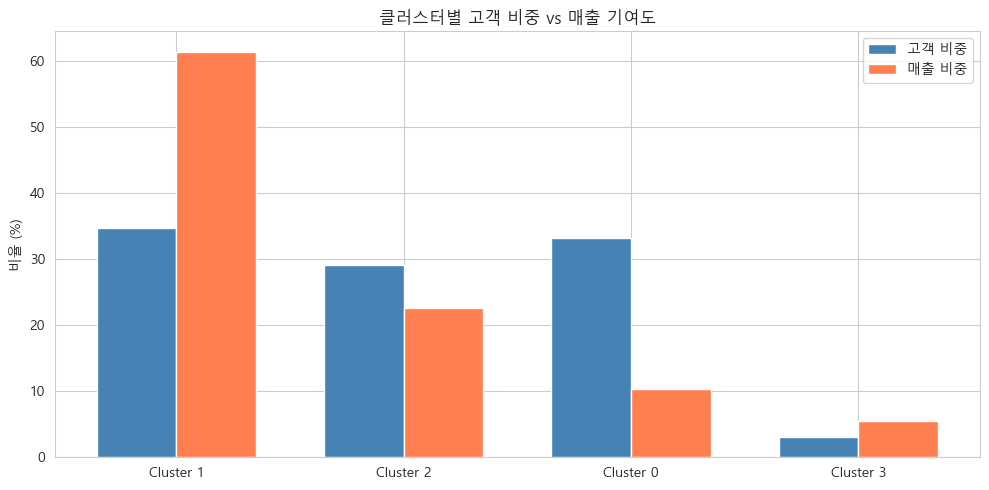

In [10]:
# 클러스터별 고객 비중 vs 매출 비중 비교
fig, ax = plt.subplots(figsize=(10, 5))

clusters_order = cluster_summary.index.tolist()
x = np.arange(len(clusters_order))
width = 0.35

ax.bar(x - width/2, cluster_summary['고객비중(%)'].values, width,
       label='고객 비중', color='steelblue')
ax.bar(x + width/2, cluster_summary['매출비중(%)'].values, width,
       label='매출 비중', color='coral')

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}' for c in clusters_order])
ax.set_ylabel('비율 (%)')
ax.set_title('클러스터별 고객 비중 vs 매출 기여도')
ax.legend()

plt.tight_layout()
plt.show()

## 5. 규칙 기반 RFM 세그먼트와 비교

앞선 노트북에서 만든 규칙 기반 세그먼트(Champions, Loyal 등)와
K-means 클러스터가 어떻게 대응되는지 확인한다.

두 결과가 비슷하면 분류 체계가 안정적이라는 근거가 되고,
차이가 크면 어느 쪽이 더 비즈니스적으로 유의미한지 판단해야 한다.

교차 분석 (고객 수)
Cluster          0      1      2     3
Segment                               
At Risk          0   4855   8791     0
Average       8993   9031     81     0
Champions        0  14452      0     0
Hibernating   4156    155  18271     0
Loyal            0      0      0  2801
Potential    17879   3893      0     0

교차 분석 (행 비율 %)
Cluster         0      1     2      3
Segment                              
At Risk       0.0   35.6  64.4    0.0
Average      49.7   49.9   0.4    0.0
Champions     0.0  100.0   0.0    0.0
Hibernating  18.4    0.7  80.9    0.0
Loyal         0.0    0.0   0.0  100.0
Potential    82.1   17.9   0.0    0.0


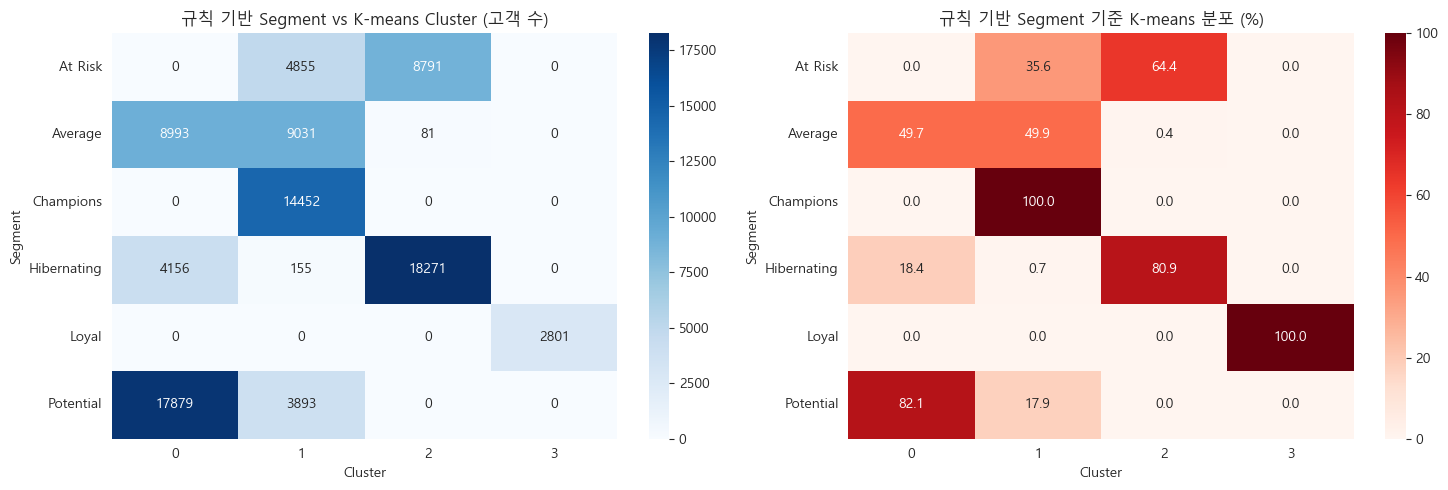

In [11]:
# 규칙 기반 세그먼트 vs K-means 클러스터 교차 분석
crosstab = pd.crosstab(rfm['Segment'], rfm['Cluster'])
crosstab_pct = pd.crosstab(rfm['Segment'], rfm['Cluster'], normalize='index') * 100

print("교차 분석 (고객 수)")
print(crosstab)

print("\n교차 분석 (행 비율 %)")
print(crosstab_pct.round(1))

# 히트맵으로 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('규칙 기반 Segment vs K-means Cluster (고객 수)')

sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Reds', ax=axes[1])
axes[1].set_title('규칙 기반 Segment 기준 K-means 분포 (%)')

plt.tight_layout()
plt.show()

## 6. 결론

### 두 접근법 비교

| 항목 | 규칙 기반 RFM | K-means |
|---|---|---|
| 분류 기준 | 도메인 지식 (사전 정의 규칙) | 데이터 기반 (거리 최소화) |
| 해석 용이성 | 높음 (조건이 명시적) | 중간 (사후 해석 필요) |
| 데이터 의존성 | 낮음 (임계값 고정) | 높음 (분포에 민감) |
| 비즈니스 적용 | 즉시 가능 | 클러스터 명명 후 가능 |

### 활용 방향

두 방법은 상호 보완적이다.
- 규칙 기반은 마케팅 팀 커뮤니케이션에 적합 (조건이 명확)
- K-means는 미발견 패턴 탐색에 유용 (데이터가 자연스럽게 군집을 형성하는지 확인)

본 분석에서 두 결과가 어느 정도 일치한다면 분류 체계가 안정적이라는 신호이며,
차이가 크다면 비즈니스 정의를 재검토할 여지가 있다.

### 교차 분석 핵심 발견

1. **VIP 그룹의 일관성**
   - Champions가 K-means Cluster 1에 100% 매칭
   - Loyal이 K-means Cluster 3에 100% 매칭
   - 두 방법이 핵심 고객 식별에서 동일한 결론에 도달함

2. **At Risk의 이질성**
   - 규칙 기반에서 'At Risk'로 분류된 고객이 K-means에서는 두 그룹으로 분리
   - 36%는 아직 매출 가치가 높은 그룹 (Cluster 1)
   - 64%는 사실상 휴면 상태 (Cluster 2)
   - 마케팅 액션을 차등화할 근거 확보

3. **분류 체계의 신뢰성**
   - 핵심 세그먼트(Champions, Loyal, Hibernating)에서 80% 이상 일치
   - 사전 정의 규칙이 데이터 분포와 일관됨을 확인

### 비즈니스 활용

- 일상 운영: 규칙 기반 분류 사용 (조건이 명시적이라 마케팅 팀 적용 용이)
- 심화 분석: K-means 결과로 At Risk 그룹 세분화 적용

In [12]:
# 클러스터링 결과 저장
rfm.to_csv('../data/rfm_with_cluster.csv', index=False)
print(f"저장 완료: {len(rfm):,}행")

저장 완료: 93,358행
